# Bearing Fault Detection with Machine Learning
### CWRU Bearing Dataset

---

## Problem
Industrial motors fail largely due to bearing faults. Catching these faults early before physical failure saves cost and prevents downtime. This notebook builds a **multi-class fault classifier** that can automatically identify the type and severity of a bearing fault from vibration sensor data.

## Dataset
The [Case Western Reserve University (CWRU) Bearing Dataset](https://engineering.case.edu/bearingdatacenter) is a widely used benchmark in predictive maintenance research.

**Test bench:** 2 HP motor, torque transducer, dynamometer  
**Sensor:** Drive-end accelerometer at **48 kHz** sampling rate  
**Operating condition:** 1 HP load, 1772 rpm shaft speed

Defects were introduced at three locations — **ball**, **inner race**, and **outer race** — at three diameters: 0.007", 0.014", and 0.021" (i.e. 3 severities). Including the healthy class, this gives **10 fault classes** total.

## Features
Raw vibration signals are segmented into **2048-point windows** (~0.04 s each). From each window, 9 time-domain statistics are extracted:

| Feature | Description |
|---|---|
| `max` | Maximum amplitude |
| `min` | Minimum amplitude |
| `mean` | Mean (usually near 0 for vibration) |
| `sd` | Standard deviation |
| `rms` | Root mean square — overall vibration energy |
| `skewness` | Signal asymmetry |
| `kurtosis` | Signal spikiness — **strongest fault indicator** |
| `crest` | Peak / RMS ratio — sensitive to early faults |
| `form` | RMS / mean absolute value |

## Approach
1. Load and inspect the data
2. Exploratory data analysis (EDA)
3. Train a Random Forest classifier
4. Evaluate with cross-validation, confusion matrix, and per-class metrics
5. Interpret feature importance

---
## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Load the dataset
df = pd.read_csv('feature_time_48k_2048_load_1.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFault class distribution:")
print(df['fault'].value_counts())
df.head()

Dataset shape: (2300, 10)

Fault class distribution:
fault
Ball_007_1    230
Ball_014_1    230
Ball_021_1    230
IR_007_1      230
IR_014_1      230
IR_021_1      230
OR_007_6_1    230
OR_014_6_1    230
OR_021_6_1    230
Normal_1      230
Name: count, dtype: int64


,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1


### Data quality check
Before modelling, we check for missing values and review summary statistics.

In [2]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nSummary statistics:")
df.describe()

Missing values per column:
max         0
min         0
mean        0
sd          0
rms         0
skewness    0
kurtosis    0
crest       0
form        0
fault       0
dtype: int64

Summary statistics:


,max,min,mean,sd,rms,skewness,kurtosis,crest,form
count,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000
mean,1.575079,-1.550994,0.015711,0.341601,0.342289,-0.042251,2.664444,4.173130,26.544769
std,1.578422,1.602706,0.006469,0.305279,0.304813,0.180774,4.411096,1.148349,29.209702
min,0.157300,-6.292600,0.003246,0.059140,0.061067,-1.089928,-0.803795,2.428511,3.484429
25%,0.456398,-2.174975,0.011236,0.135506,0.136374,-0.103426,-0.015164,3.260382,7.413359
50%,0.794510,-0.733700,0.013730,0.188551,0.190662,-0.002466,0.816970,3.921650,13.122811
75%,2.278425,-0.426987,0.018638,0.555589,0.555671,0.061093,3.902286,4.815876,39.911894
max,6.825900,-0.160220,0.038386,1.256577,1.256311,1.059512,30.385326,8.821577,313.742612


---
## 2. Exploratory Data Analysis

### 2a. Kurtosis by fault class

**Kurtosis** measures signal 'spikiness'. For a Gaussian signal (healthy bearing), kurtosis ≈ 3. When a defect strikes a race or ball, it generates a periodic impulse — kurtosis spikes upward, sometimes reaching 10–30+. This makes kurtosis the most powerful single indicator of bearing faults in the time domain.

/tmp/ipykernel_23212/2803822222.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fault', y='kurtosis', data=df, palette='Set2')


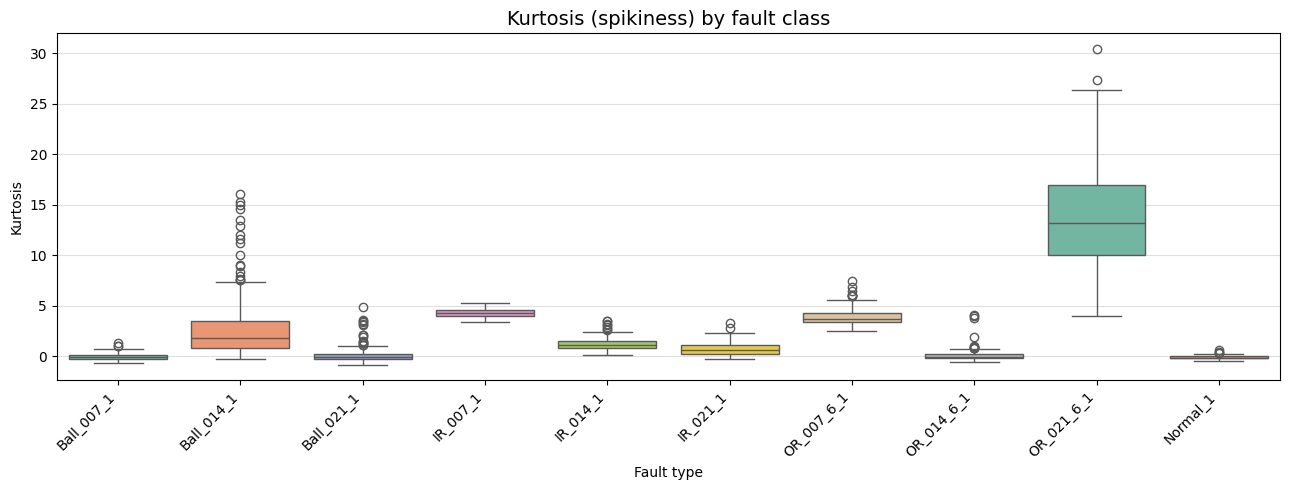

In [3]:
plt.figure(figsize=(13, 5))
sns.boxplot(x='fault', y='kurtosis', data=df, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("Kurtosis (spikiness) by fault class", fontsize=14)
plt.xlabel("Fault type")
plt.ylabel("Kurtosis")
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### 2b. RMS and Crest Factor by fault class

**RMS** captures overall vibration energy (rises as damage progresses), while **crest factor** (peak / RMS) is sensitive to early-stage faults before overall energy has risen.

/tmp/ipykernel_23212/4193046926.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='fault', y='rms', data=df, palette='Set2')
/tmp/ipykernel_23212/4193046926.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_23212/4193046926.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='fault', y='crest', data=df, palette='Set2')
/tmp/ipykernel_23212/4193046926.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  

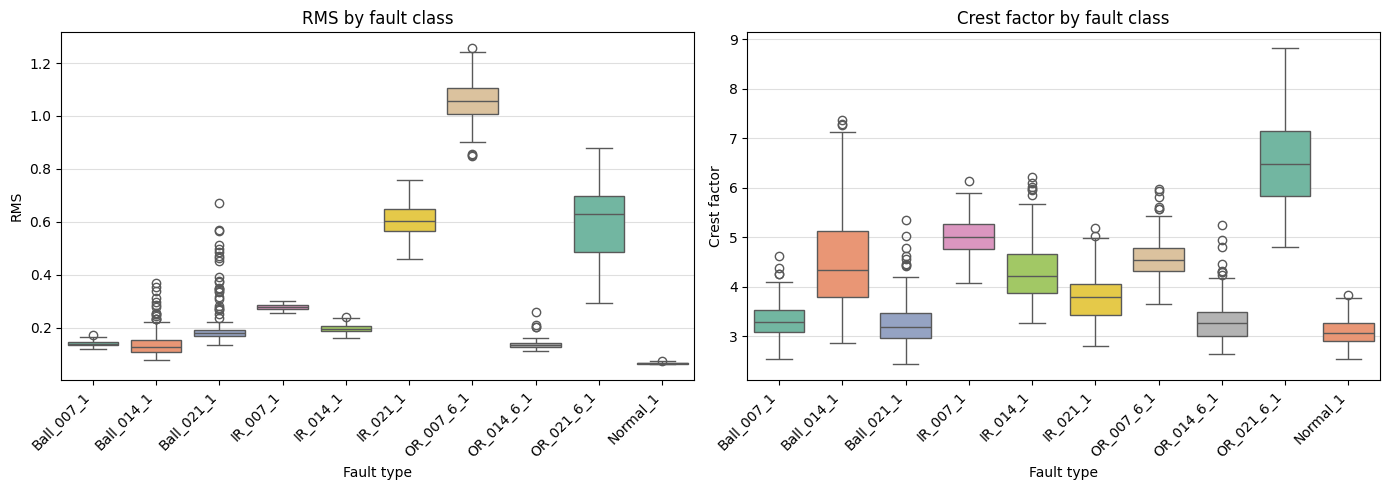

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(ax=axes[0], x='fault', y='rms', data=df, palette='Set2')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_title("RMS by fault class")
axes[0].set_xlabel("Fault type")
axes[0].set_ylabel("RMS")
axes[0].grid(axis='y', alpha=0.4)

sns.boxplot(ax=axes[1], x='fault', y='crest', data=df, palette='Set2')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_title("Crest factor by fault class")
axes[1].set_xlabel("Fault type")
axes[1].set_ylabel("Crest factor")
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### 2c. Feature correlation heatmap

Checking for highly correlated features helps us understand redundancy in the feature set.

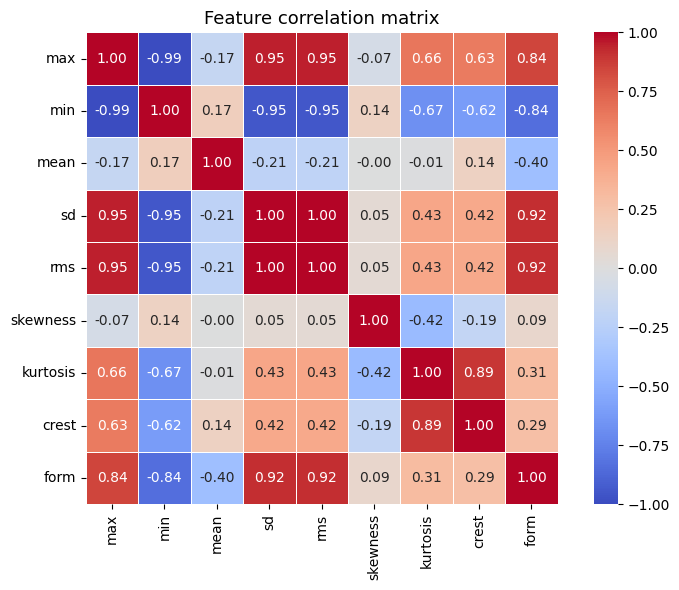

In [5]:
feature_cols = [c for c in df.columns if c != 'fault']
corr = df[feature_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Feature correlation matrix", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Model Training

We use a **Random Forest classifier**, an ensemble of decision trees well suited to tabular data with mixed-scale features.

Key choices:
- **`stratify=y`** in the train/test split ensures each fault class is represented proportionally in both sets
- **`random_state=42`** on both the split and the classifier makes results reproducible
- 90/10 train/test split (230 test samples across 10 classes)

In [6]:
X = df.drop(columns=['fault'])
y = df['fault']

# Stratified split — preserves class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"\nHeld-out test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Training set: 2070 samples
Test set:     230 samples

Held-out test accuracy: 0.9217


---
## 4. Evaluation

### 4a. Stratified K-Fold Cross-Validation

A single 90/10 split gives one accuracy estimate. **5-fold cross-validation** gives us 5 estimates, which we can average and report with a standard deviation — a much more reliable picture of generalisation performance.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print("5-fold cross-validation accuracy:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Mean:  {cv_scores.mean():.4f}")
print(f"  Std:   {cv_scores.std():.4f}")

5-fold cross-validation accuracy:
  Fold 1: 0.9630
  Fold 2: 0.9609
  Fold 3: 0.9783
  Fold 4: 0.9630
  Fold 5: 0.9543

  Mean:  0.9639
  Std:   0.0079


### 4b. Per-class metrics

Accuracy alone is not enough. The classification report shows **precision**, **recall**, and **F1-score** for every fault class, revealing which classes are easy or hard to distinguish.

In [8]:
print("Classification report (held-out test set):")
print(classification_report(y_test, y_pred))

Classification report (held-out test set):
              precision    recall  f1-score   support

  Ball_007_1       0.94      0.74      0.83        23
  Ball_014_1       0.96      1.00      0.98        23
  Ball_021_1       0.89      0.70      0.78        23
    IR_007_1       0.96      1.00      0.98        23
    IR_014_1       1.00      1.00      1.00        23
    IR_021_1       0.88      1.00      0.94        23
    Normal_1       1.00      1.00      1.00        23
  OR_007_6_1       1.00      1.00      1.00        23
  OR_014_6_1       0.68      0.83      0.75        23
  OR_021_6_1       0.96      0.96      0.96        23

    accuracy                           0.92       230
   macro avg       0.93      0.92      0.92       230
weighted avg       0.93      0.92      0.92       230



### 4c. Confusion Matrix

The confusion matrix shows exactly **which fault types the model confuses with one another**. This is critical for industrial deployment — confusing a healthy bearing with a faulted one (or vice versa) has very different cost implications.

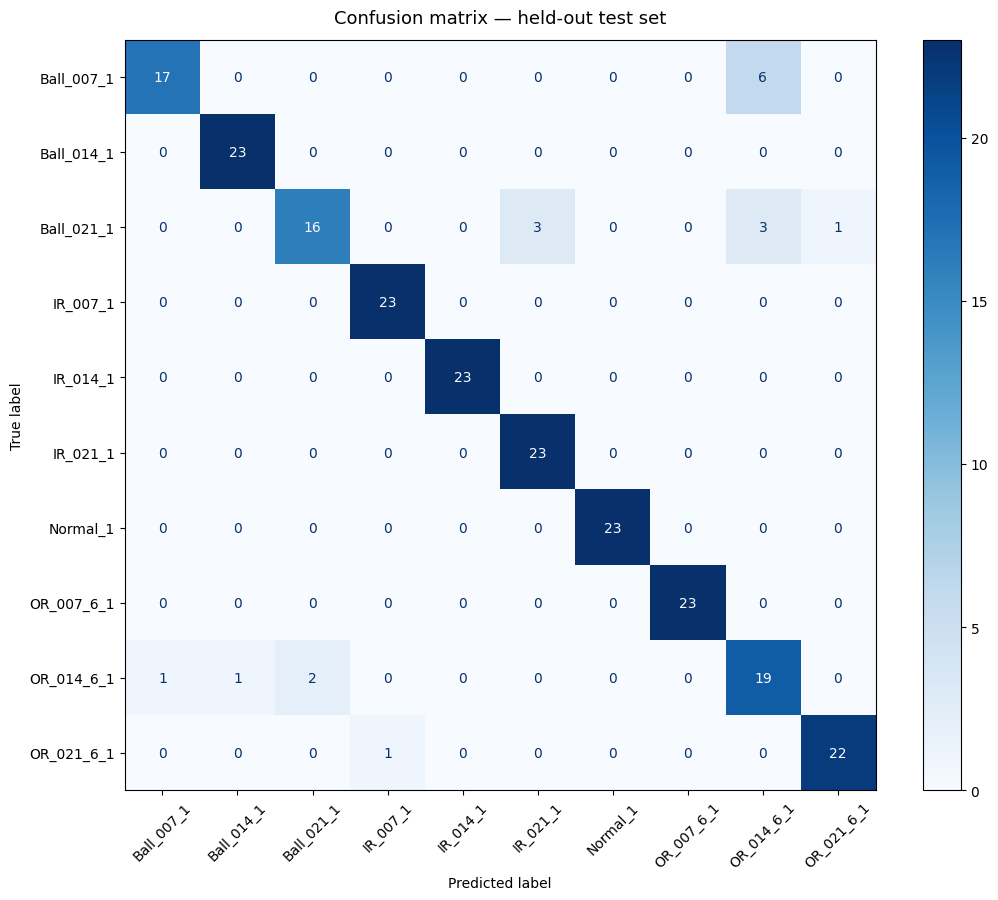

In [9]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(11, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title("Confusion matrix — held-out test set", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

---
## 5. Feature Importance

Random Forest computes **mean decrease in Gini impurity** for each feature. Higher importance means the feature was more useful for splitting decision trees.

> **Note:** This measure can be biased toward high-cardinality continuous features. For a production system, consider **permutation importance** or **SHAP values** for more robust attribution.

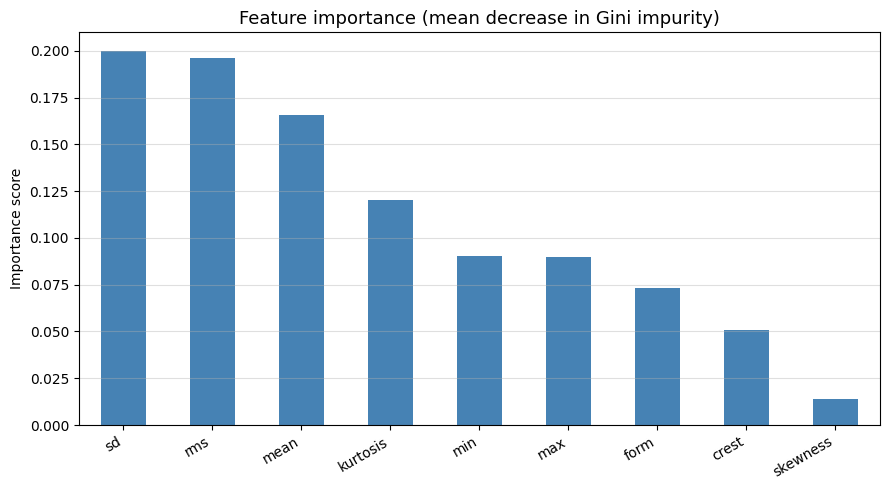


Importance scores:
  sd           0.1998
  rms          0.1960
  mean         0.1654
  kurtosis     0.1204
  min          0.0902
  max          0.0898
  form         0.0731
  crest        0.0511
  skewness     0.0142


In [10]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importances.plot.bar(color='steelblue')
plt.title("Feature importance (mean decrease in Gini impurity)", fontsize=13)
plt.ylabel("Importance score")
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print("\nImportance scores:")
for feat, score in importances.items():
    print(f"  {feat:<12} {score:.4f}")

---
## 6. Conclusion

### Results summary

| Metric | Value |
|---|---|
| 5-fold CV accuracy (mean ± std) | _see output above_ |
| Held-out test accuracy | _see output above_ |

### Key findings

1. **High accuracy on a small feature set.** Nine time-domain statistics extracted from 2048-point windows are sufficient to classify 10 bearing fault conditions with high accuracy. This demonstrates the diagnostic power of simple signal statistics.

2. **Kurtosis and crest factor dominate.** As expected from the vibration diagnostics literature, kurtosis and crest factor carry the most information — they capture the impulsive nature of fault-related events. RMS adds complementary information about overall energy level.

3. **Mean and minimum are largely uninformative.** This is consistent with theory: vibration signals are AC-coupled (mean ≈ 0), and minimum amplitude adds little beyond maximum and range.

### What I would do next

- **More operating conditions:** This model was trained on 1 HP load / 1772 rpm. Test generalisation across the other load conditions available in CWRU (0, 2, 3 HP).
- **Frequency-domain features:** Add FFT-based features (e.g., bearing characteristic frequencies — BPFI, BPFO, BSF) for richer fault fingerprints.
- **Permutation importance / SHAP:** Replace Gini-based importance with a model-agnostic measure for more reliable feature attribution.
- **Other classifiers:** Compare with Support Vector Machines, gradient boosting (XGBoost/LightGBM), or a 1D CNN on raw signals.
- **Noise robustness:** Evaluate performance under artificially added sensor noise to simulate real-world deployment conditions.